<a href="https://colab.research.google.com/github/Itsayazalam/LiveTranslator/blob/main/Copy_of_M1_Demo01_Credit_Reports_RAG_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a Consumer Credit Knowledge Assistant with RAG — LangChain & LangGraph

## Overview

Large language models are fluent but ungrounded: ask one a factual question and it will answer from
whatever it absorbed during training, with no way for you to check where the answer came from. For
anything that has to be *defensible* — a support answer given to a customer, a figure quoted in a
report — that is not good enough.

**Retrieval-Augmented Generation (RAG)** fixes this by changing where the answer comes from. Instead
of asking the model what it knows, we first *retrieve* the passages most relevant to the question
from a document collection we control, and then ask the model to answer **using only those
passages**, citing them as it goes. If the passages don't contain the answer, the correct output is
"I don't know" — not a guess.

In this notebook we build a question-answering assistant over two published research reports on the
**US consumer credit system**. It answers questions about them with **grounded, cited answers**.

## The two parts of this notebook

This notebook builds the *same* pipeline twice, deliberately.

- **Part A — RAG as plain Python functions.** We build the pipeline one stage at a time as ordinary
  functions: load, chunk, embed, retrieve, generate. No framework abstractions. By the end you will
  have written every moving part yourself and will know exactly what each one does.

- **Part B — the same pipeline as a LangGraph workflow.** We then re-express that identical pipeline
  as a **graph**: a state object, two nodes, and the edges between them. The nodes are thin wrappers
  around the Part A functions — *the RAG logic does not change at all*. What changes is how the steps
  are orchestrated, and that difference is what makes conditional, looping, and multi-step flows
  possible later.

Building it twice is the point. Part A shows you the machinery; Part B shows you the abstraction, and
because both run over the same corpus with the same prompts, you can see precisely what the
abstraction did and did not buy you.

## The corpus

Two reports from the **Consumer Financial Protection Bureau (CFPB)**, a US federal agency. Both are
works of the US federal government and therefore in the public domain, so they can be redistributed
and reused freely.

| Report | Year | What it covers |
|--------|------|----------------|
| *CFPB Data Point: Credit Invisibles* | 2015 | How many US adults have no credit record at all, and how many have a record that cannot be scored |
| *CFPB Data Point: Becoming Credit Visible* | 2017 | How people acquire their **first** credit record — which products trigger it, and the role of co-borrowers and authorized users |

The second report is a direct follow-up to the first by the same research team, which makes them a
useful pair: they overlap enough that some questions are answered by **both** documents (producing
genuine multi-source citations), but each also owns territory the other does not cover.

## Technical stack

| Component | Technology | Role |
|-----------|-----------|------|
| LLM | OpenAI chat model | generates the grounded, cited answer |
| Embeddings | `text-embedding-3-small` | turns text into vectors for semantic search |
| Vector store | ChromaDB | stores the chunks and serves similarity search |
| PDF loading | PyMuPDF | extracts text from the reports |
| Chunking | `RecursiveCharacterTextSplitter` | token-aware splitting on natural boundaries |
| Orchestration (Part B) | LangGraph | expresses the pipeline as a state graph |

## Pipeline at a glance

![](https://i.imgur.com/lSBU1N2.png)

## What we build, in order

**Part A**

1. **Load** each PDF and join its pages into one continuous text
2. **Chunk** that text with a token-aware recursive splitter, attaching citation metadata
3. **Embed** the chunks and store them in a Chroma vector database
4. **Retrieve** the most relevant chunks for a question, filtering out weak matches
5. **Generate** an answer grounded in those chunks, with inline `[n]` citations and a references list
6. **Test** the pipeline against five different kinds of question, including ones it should refuse

**Part B**

7. Define the graph **state**
8. Wrap steps 4 and 5 as graph **nodes**
9. **Wire and compile** the graph, then run the same questions through it

---

## Environment setup

We install the LangChain v1 stack plus the pieces the pipeline needs: the OpenAI integration for the
chat and embedding models, Chroma for the vector store, PyMuPDF for reading PDFs, and the token-aware
text splitter.

> **On pinning versions.** Every package below is pinned to an exact version. This matters more than
> it looks: the LangChain ecosystem moves quickly, and an unpinned `pip install` can silently pull a
> release with a changed API, breaking the notebook. Pinning means this notebook behaves identically
> today and six months from now.

In [ ]:
# ---------------------------------------------------------------------------
# Pinned dependencies. Colab ships without these, so we install them here.
#
# Everything is pinned to an exact version so this notebook is reproducible.
# ---------------------------------------------------------------------------

# LangChain v1 core + graph runtime
!uv pip install --system -q langchain==1.3.13
!uv pip install --system -q langgraph==1.2.9
!uv pip install --system -q langchain-openai==1.4.2


# Vector store, PDF loading, chunking
!uv pip install --system -q langchain-chroma==1.1.0
!uv pip install --system -q langchain-community==0.4.2
!uv pip install --system -q langchain-text-splitters==1.1.2
!uv pip install --system -q pymupdf==1.28.0
!uv pip install --system -q tiktoken==0.13.0

In [ ]:
# ---------------------------------------------------------------------------
# Imports used throughout the notebook.
# ---------------------------------------------------------------------------
import os
import glob
import getpass
from datetime import datetime, timezone

import tiktoken

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_chroma import Chroma

from IPython.display import display, Markdown

print("Imports loaded.")

/tmp/ipykernel_1061/1429936676.py:12: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader


Imports loaded.


### API authentication

We read the OpenAI API key with `getpass` so the key is never printed into the notebook output and is
never saved into the `.ipynb` file. The same key is used for both the chat model and the embedding
model.

In [ ]:
# getpass hides the input, so the key never appears in the notebook output or the saved file.
os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

Enter your OpenAI API key: ··········


### Model setup

Two models are needed, and they do different jobs:

- a **chat model**, which writes the final grounded answer from the retrieved passages;
- an **embedding model**, which converts text into vectors so we can search the corpus by meaning
  rather than by keyword.

We set `temperature=0` on the chat model. For a grounded question-answering system we want the answer
to be as reproducible and as faithful to the sources as possible — creativity is not the goal here.

> **Change the model names below if you need to.** They are pulled out as constants precisely so you
> only have to edit one place. Any current OpenAI chat model will work.

In [ ]:
# ---------------------------------------------------------------------------
# Model configuration. Pulled out as constants so there is exactly one place
# to change if you want to use a different model.
# ---------------------------------------------------------------------------
CHAT_MODEL = "gpt-4.1-mini"              # writes the grounded answer
EMBED_MODEL = "text-embedding-3-small"   # converts text to vectors for search

llm = ChatOpenAI(
    model=CHAT_MODEL,
    temperature=0,     # deterministic: we want faithful answers, not creative ones
)

embedder = OpenAIEmbeddings(
    model=EMBED_MODEL,
)

# Quick connectivity check before we build anything on top of these.
print("Chat model says:", llm.invoke("Reply with 'OK' if you can read this.").content)

Chat model says: OK


---

## The corpus: two CFPB reports

Our knowledge base is two research reports from the **Consumer Financial Protection Bureau**:

**1. *CFPB Data Point: Credit Invisibles* (2015)** — establishes the size of the problem. It estimates how
many US adults have **no credit record at all** with a nationwide credit reporting company ("credit
invisible") and how many have a record that exists but **cannot be scored** by a standard credit
scoring model. It also breaks these populations down by age and by neighborhood income level.

**2. *CFPB Data Point: Becoming Credit Visible* (2017)** — the follow-up study, which asks the
opposite question: how do people **get out** of credit invisibility? It traces the "entry product"
that created each person's credit record, and looks at how often people relied on someone else — as
a co-borrower, or by being added as an authorized user on another person's account.

**Why these two, together.** They share a subject and a research team, so a question like *"what does
it mean to be credit invisible?"* is legitimately answered by **both** documents, and the pipeline
will cite both. But each also owns ground the other doesn't: population sizes live only in the first,
and the mechanics of acquiring a first credit record live only in the second. That mix is what makes
retrieval interesting — the system has to work out which document actually holds the answer.

Both reports are US federal government publications and therefore **public domain**.

In [ ]:
# ---------------------------------------------------------------------------
# Fetch the workshop data zip from Google Drive and unpack it.
#
# The zip is expected to contain a single folder, `credit_docs/`, holding the
# two CFPB report PDFs. After this cell runs, PDF_DIR points at that folder.
#
# >>> REPLACE ZIP_FILE_ID with the Google Drive file ID of the workshop zip.
#     For a share link like
#         https://drive.google.com/file/d/1AbCdEfGhIjKlMnOp/view?usp=sharing
#     the file ID is the part between /d/ and /view  ->  1AbCdEfGhIjKlMnOp
#
# If you would rather upload the zip by hand, skip gdown entirely: use the Colab
# file browser on the left to upload it, then run only the unzip line below.
# ---------------------------------------------------------------------------
ZIP_FILE_ID = "1htAqyqsQuQvSH7CbUPRG0oYDopSlb7xd"
ZIP_NAME = "credit_docs.zip"
PDF_DIR = "credit_docs"

# Download (skipped automatically if the zip is already present).
# Modern gdown takes the bare file ID as a positional argument; the old
# `--id` flag is deprecated. If the file ID alone fails, pass the full share
# URL with --fuzzy instead:
#     !gdown --fuzzy "https://drive.google.com/file/d/<ID>/view" -O $ZIP_NAME
if not os.path.exists(ZIP_NAME):
    !gdown $ZIP_FILE_ID -O $ZIP_NAME

# Unpack quietly, overwriting any previous extraction
!unzip -o -q $ZIP_NAME

# Confirm what we actually got. If this list is empty, either the download
# failed or the folder name inside the zip is not `credit_docs/` -- fix that
# before going any further, because every later stage depends on it.
pdf_files = sorted(glob.glob(os.path.join(PDF_DIR, "*.pdf")))
print(f"PDFs found in '{PDF_DIR}/':")
for pdf_path in pdf_files:
    size_mb = os.path.getsize(pdf_path) / 1_000_000
    print(f"  - {os.path.basename(pdf_path)}  ({size_mb:.1f} MB)")

Downloading...
From: https://drive.google.com/uc?id=1htAqyqsQuQvSH7CbUPRG0oYDopSlb7xd
To: /content/credit_docs.zip
100% 642k/642k [00:00<00:00, 8.86MB/s]
PDFs found in 'credit_docs/':
  - BecomingCreditVisible_Data_Point_Final.pdf  (0.2 MB)
  - cfpb_data-point-credit-invisibles.pdf  (0.5 MB)


### A catalog of authoritative source metadata

Before we touch the text, we write down the bibliographic details of each report by hand.

This looks like busywork but it is doing something important. Later, the model will be asked to cite
its sources. If we leave it to infer the title, publisher, and year from the PDF text, it will
sometimes get them subtly wrong — a slightly reworded title, the wrong year — and a citation that is
*almost* right is worse than no citation, because it looks trustworthy while being unverifiable.

So we keep a `PDF_CATALOGUE` mapping each filename to its authoritative details, attach those details
to every chunk as metadata, and hand them to the model already formatted. The model never has to
guess who wrote something or when.

> **The dictionary keys must match the filenames on disk exactly** — including case and punctuation.
> A mismatch here is the single most common cause of a `KeyError` further down.

In [ ]:
# ---------------------------------------------------------------------------
# Authoritative bibliographic metadata for each report, keyed by the EXACT
# filename as it appears on disk. These values are attached to every chunk and
# handed to the model pre-formatted, so citations never rely on the model
# inferring a title, publisher, or year from the document text.
#
# issuer_short is used in the visible citation, because spelling out
# "Consumer Financial Protection Bureau" on every line makes the reference
# list hard to read.
# ---------------------------------------------------------------------------
PDF_CATALOGUE = {
    "cfpb_data-point-credit-invisibles.pdf": {
        "doc_title": "CFPB Data Point: Credit Invisibles",
        "issuer": "Consumer Financial Protection Bureau",
        "issuer_short": "CFPB",
        "year": 2015,
    },
    "BecomingCreditVisible_Data_Point_Final.pdf": {
        "doc_title": "CFPB Data Point: Becoming Credit Visible",
        "issuer": "Consumer Financial Protection Bureau",
        "issuer_short": "CFPB",
        "year": 2017,
    },
}

# Sanity check: every cataloged filename should actually exist on disk, and
# every PDF on disk should be cataloged. Catching this now saves confusion later.
on_disk = {os.path.basename(p) for p in pdf_files}
catalogued = set(PDF_CATALOGUE)

missing_on_disk = catalogued - on_disk
uncatalogued = on_disk - catalogued

if missing_on_disk:
    print("WARNING - in the catalog but not found on disk:", missing_on_disk)
if uncatalogued:
    print("WARNING - on disk but not in the catalog:", uncatalogued)
if not missing_on_disk and not uncatalogued:
    print(f"Catalog matches disk: {len(catalogued)} report(s) ready.")

Catalog matches disk: 2 report(s) ready.


---
# Part A — RAG as plain Python functions

We now build the pipeline stage by stage. Each stage is an ordinary Python function, and after each
one we look at what it produced before moving on.

## Stage 1 — Load each report as one continuous text

We read each PDF with **`PyMuPDFLoader`**, which returns one `Document` per page. We then **join those
pages into a single continuous string** per report.

> **Why join the pages instead of chunking page by page?** A PDF page break is a printing artifact,
> not a change of subject. A sentence, a paragraph, or an argument routinely runs across one. If we
> chunked each page independently, every page boundary would become a hard cut, and any idea that
> straddled one would be split into two half-chunks — neither of which retrieves well. Joining the
> pages first lets the splitter in Stage 2 choose boundaries based on the *text*, not on where the
> printer happened to stop. This is standard practice.

In [ ]:
# ---------------------------------------------------------------------------
# Stage 1: load each PDF and join its pages into one continuous text.
#
# PyMuPDFLoader returns a list of Documents, one per page. We concatenate the
# page contents with a blank line between them, so the splitter in Stage 2 sees
# one continuous document per report rather than a series of pages.
# ---------------------------------------------------------------------------
PAGE_SEP = "\n\n"


def load_document(filename):
    """Load one PDF and return its full text as a single string.

    Args:
        filename: PDF filename (not a full path) as it appears in PDF_DIR.

    Returns:
        dict with keys:
          filename  - the filename, used to look up metadata in PDF_CATALOGUE
          text      - the whole report as one continuous string
          num_pages - how many pages were read (useful as a sanity check)
    """
    path = os.path.join(PDF_DIR, filename)
    pages = PyMuPDFLoader(path).load()

    # Join page texts into one continuous string
    text = PAGE_SEP.join(page.page_content for page in pages)

    return {"filename": filename, "text": text, "num_pages": len(pages)}


def load_documents(catalogue):
    """Load every report listed in the catalogue.

    Args:
        catalogue: the PDF_CATALOGUE dict (we only use its keys here).

    Returns:
        list of the dicts returned by load_document().
    """
    documents = []
    for filename in catalogue:
        doc = load_document(filename)
        documents.append(doc)
        print(f"[load] {filename}")
        print(f"       {len(doc['text']):,} characters across {doc['num_pages']} pages")
    return documents


documents = load_documents(PDF_CATALOGUE)

[load] cfpb_data-point-credit-invisibles.pdf
       58,774 characters across 37 pages
[load] BecomingCreditVisible_Data_Point_Final.pdf
       54,961 characters across 35 pages


In [ ]:
# A quick look at the start of the first report, to confirm the text extracted
# cleanly and we are not staring at garbled output or an empty string.
print(documents[0]["filename"])
print("-" * 80)
print(documents[0]["text"][:3000])

cfpb_data-point-credit-invisibles.pdf
--------------------------------------------------------------------------------
DRAFT 
 
 
 
 
 
May 2015 
Data Point: 
Credit Invisibles 
The CFPB Office of Research

2 
CFPB DATA POINT: CREDIT INVISIBLES 
 
Kenneth P. Brevoort 
 
Philipp Grimm 
 
Michelle Kambara 
This is another in an occasional series of publications from the Consumer Financial Protection 
Bureau’s Office of Research.  These publications are intended to further the Bureau’s objective of 
providing an evidence-based perspective on consumer financial markets, consumer behavior, 
and regulations to inform the public discourse.

3 
CFPB DATA POINT: CREDIT INVISIBLES 
Table of Contents 
Table of Contents ........................................................................................................ 3 
1. Introduction ........................................................................................................... 4 
2. Data ....................................

## Stage 2 — Chunk the text, with citation metadata attached

An entire report is far too large to hand to a model as context, and it would be wasteful anyway —
most of it is irrelevant to any given question. So we split each report into **chunks**: passages
small enough to be retrieved and read selectively.

We use `RecursiveCharacterTextSplitter.from_tiktoken_encoder()`, which does two things that matter:

- **Recursive splitting on natural boundaries.** It tries to split on paragraph breaks first, then
  line breaks, then sentences, then words — only breaking mid-word as a last resort. Chunks therefore
  tend to end where a human would end them.
- **Token-aware sizing.** Chunk size is measured in *tokens*, the unit the model actually consumes,
  not characters. We cap chunks at **1500 tokens** with **200 tokens of overlap** between consecutive
  chunks, so an idea sitting near a boundary appears in full in at least one chunk.

The second half of this stage is the part people skip and then regret: **every chunk gets metadata
attached**. Without it, a retrieved chunk is an anonymous block of text and citation is impossible.
With it, we know which report a chunk came from, who published it, and when — which is exactly what
we need to build a reference list the reader can verify.

In [ ]:
# ---------------------------------------------------------------------------
# Stage 2: split each report into token-capped chunks, and attach the
# bibliographic metadata that makes citation possible.
#
# We identify the tokenizer by model name, because each model is paired with a
# specific tokenizer. Counting tokens with that model's own encoding means the
# chunk size we set is the chunk size the model actually experiences.
# ---------------------------------------------------------------------------
MODEL_NAME = "gpt-4.1"
CHUNK_SIZE = 1500      # tokens per chunk (hard cap)
CHUNK_OVERLAP = 200    # tokens repeated between consecutive chunks

splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    model_name=MODEL_NAME,
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
)

# Used further down purely to report token counts when inspecting a chunk.
_enc = tiktoken.encoding_for_model(MODEL_NAME)


def chunk_documents(documents, catalogue):
    """Split every report into chunks tagged with citation metadata.

    Args:
        documents: list of dicts from load_documents().
        catalogue: PDF_CATALOGUE, used to look up each report's bibliographic details.

    Returns:
        list of LangChain Document objects, each one chunk with full metadata.
    """
    # One timestamp for the whole ingestion run, so every chunk records when it
    # entered the vector store. Useful in real systems for spotting stale content.
    ingested_at = datetime.now(timezone.utc).isoformat(timespec="seconds")

    all_chunks = []

    for doc in documents:
        meta = catalogue[doc["filename"]]

        # Split this report's text. We wrap the raw string in a Document first
        # because split_documents() expects Documents, not plain strings.
        pieces = splitter.split_documents([Document(page_content=doc["text"])])

        for idx, piece in enumerate(pieces):
            piece.metadata = {
                "source": doc["filename"],
                "doc_title": meta["doc_title"],
                "issuer": meta["issuer"],
                "issuer_short": meta["issuer_short"],
                "year": meta["year"],
                "chunk_index": idx,          # position within this report
                "ingested_at": ingested_at,
            }
            all_chunks.append(piece)

        print(f"[chunk] {doc['filename']} -> {len(pieces)} chunks")

    return all_chunks


chunks = chunk_documents(documents, PDF_CATALOGUE)
print(f"\n[chunk] total chunks across all reports: {len(chunks)}")

[chunk] cfpb_data-point-credit-invisibles.pdf -> 11 chunks
[chunk] BecomingCreditVisible_Data_Point_Final.pdf -> 11 chunks

[chunk] total chunks across all reports: 22


In [ ]:
# Inspect a single chunk: how many tokens it holds, what metadata is attached,
# and what the text actually looks like. This is the unit the retriever will
# return and the model will read, so it is worth seeing one up close.
sample = chunks[2]

print("TOKENS:", len(_enc.encode(sample.page_content)))
print("METADATA:")
for k, v in sample.metadata.items():
    print(f"   {k}: {v}")
print("-" * 80)
print(sample.page_content)

TOKENS: 1184
METADATA:
   source: cfpb_data-point-credit-invisibles.pdf
   doc_title: CFPB Data Point: Credit Invisibles
   issuer: Consumer Financial Protection Bureau
   issuer_short: CFPB
   year: 2015
   chunk_index: 2
   ingested_at: 2026-08-08T04:31:53+00:00
--------------------------------------------------------------------------------
8 
CFPB DATA POINT: CREDIT INVISIBLES 
There are two types of unscored records in the CCP.5  The first, “insufficient unscored” records, 
do not contain enough information to generate the score, meaning either that the record 
contained too few reported accounts or accounts that did not have a sufficiently long credit 
history.  The second type, “stale unscored” records, do not contain any recently reported 
information.  Our analysis examines these two types of unscored credit records separately. 
When available, a year of birth is included in the CCP for each record.6  We use this information 
to calculate the age of each consumer at the end of

## Stage 3 — Embed the chunks and store them in Chroma

To search by *meaning* rather than by keyword, we convert each chunk into an **embedding**: a vector
of numbers positioned so that passages about similar topics land near each other. A question is
embedded the same way, and retrieval becomes a nearest-neighbor lookup — which is why a question
phrased as *"how do people get their first credit card?"* can match a passage that never uses those
exact words.

We store the vectors in **Chroma**, configured with **cosine distance** (the standard choice for text
embeddings, since it compares direction rather than magnitude).

Each chunk is given a **stable ID** of the form `<filename-stem>::<chunk_index>`. This means re-running
the notebook *overwrites* existing entries instead of inserting a second copy of everything — without
it, a second run silently doubles your corpus and skews every subsequent retrieval.

In [ ]:
# ---------------------------------------------------------------------------
# Stage 3: embed the chunks and store them in a local Chroma collection.
#
# Note on IDs: each chunk gets a deterministic ID built from its source
# filename and its position in that file. Re-running this cell therefore
# UPDATES the existing rows rather than appending duplicates.
# ---------------------------------------------------------------------------
CHROMA_DIR = "credit_reports_db"
COLLECTION_NAME = "credit_reports"

vector_db = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embedder,
    collection_metadata={"hnsw:space": "cosine"},   # cosine distance for text
    persist_directory=CHROMA_DIR,
)


def chunk_id(doc):
    """Build a stable, unique ID for a chunk: '<filename-stem>::<chunk_index>'."""
    stem = os.path.splitext(doc.metadata["source"])[0]
    return f"{stem}::{doc.metadata['chunk_index']}"


ids = [chunk_id(c) for c in chunks]

# This is the call that actually sends text to the embedding model, so it is
# the slowest cell in the notebook -- expect a short wait.
vector_db.add_documents(documents=chunks, ids=ids)

print(f"[store] {vector_db._collection.count()} chunks stored in '{CHROMA_DIR}/'")

[store] 22 chunks stored in 'credit_reports_db/'


In [ ]:
vector_db.get(limit=1)

{'ids': ['cfpb_data-point-credit-invisibles::0'],
 'embeddings': None,
 'documents': ['DRAFT \n \n \n \n \n \nMay 2015 \nData Point: \nCredit Invisibles \nThe CFPB Office of Research\n\n2 \nCFPB DATA POINT: CREDIT INVISIBLES \n\uf0a7 \nKenneth P. Brevoort \n\uf0a7 \nPhilipp Grimm \n\uf0a7 \nMichelle Kambara \nThis is another in an occasional series of publications from the Consumer Financial Protection \nBureau’s Office of Research.  These publications are intended to further the Bureau’s objective of \nproviding an evidence-based perspective on consumer financial markets, consumer behavior, \nand regulations to inform the public discourse.\n\n3 \nCFPB DATA POINT: CREDIT INVISIBLES \nTable of Contents \nTable of Contents ........................................................................................................ 3 \n1. Introduction ........................................................................................................... 4 \n2. Data ........................

## Stage 4 — Retrieve the relevant chunks

Given a question, we now fetch the chunks most likely to contain the answer.

We use a **similarity-score-threshold** retriever, which takes two settings:

- **`top_k`** — the maximum number of chunks to return.
- **`score_threshold`** — a minimum similarity score. Anything scoring below it is discarded, *even
  if that leaves us with fewer than `top_k` chunks, or with none at all.*

That second setting is doing more work than it appears to. A plain top-k retriever always returns
exactly k chunks — so if you ask an off-topic question, it hands back the k *least irrelevant* chunks
in the corpus and the model, seeing context, feels obliged to construct an answer from it. The
threshold is what lets the pipeline come back **empty**, which is what makes an honest "I don't know"
possible. We will see this working in the test questions at the end of Part A.

In [ ]:
# ---------------------------------------------------------------------------
# Stage 4: retrieve the chunks most relevant to a question.
#
# search_type="similarity_score_threshold" returns AT MOST top_k chunks, and
# only those scoring above score_threshold. It can legitimately return an empty
# list -- that is the behavior that lets the pipeline refuse off-topic
# questions instead of inventing an answer from weak matches.
# ---------------------------------------------------------------------------
DEFAULT_TOP_K = 5
DEFAULT_SCORE_THRESHOLD = 0.3


def retrieve_chunks(query, top_k=DEFAULT_TOP_K, score_threshold=DEFAULT_SCORE_THRESHOLD):
    """Fetch the chunks most relevant to a query.

    Args:
        query: the natural-language question.
        top_k: maximum number of chunks to return.
        score_threshold: minimum similarity score; weaker matches are dropped.

    Returns:
        list of Documents (possibly empty if nothing clears the threshold).
    """
    retriever = vector_db.as_retriever(
        search_type="similarity_score_threshold",
        search_kwargs={"k": top_k, "score_threshold": score_threshold},
    )
    return retriever.invoke(query)

In [ ]:
# Quick test of retrieval on its own, before any generation is involved.
# This cell shows the single top-ranked hit in full, so you can see exactly what
# one retrieved chunk looks like. The next cell summarizes all of them.
test_query = "Which credit products most often create a person's first credit record?"
hits = retrieve_chunks(test_query, top_k=5)

print(f"QUERY: {test_query}")
print(f"Retrieved {len(hits)} chunk(s)\n")

hits[0]

QUERY: Which credit products most often create a person's first credit record?
Retrieved 5 chunk(s)



Document(id='BecomingCreditVisible_Data_Point_Final::3', metadata={'doc_title': 'CFPB Data Point: Becoming Credit Visible', 'year': 2017, 'source': 'BecomingCreditVisible_Data_Point_Final.pdf', 'ingested_at': '2026-08-07T20:00:07+00:00', 'chunk_index': 3, 'issuer_short': 'CFPB', 'issuer': 'Consumer Financial Protection Bureau'}, page_content='TABLE 2:\nDISTRIBUTION OF ENTRY PRODUCTS BY AGE GROUP\nAge Range\n% Auto\n% Credit Cards\n% Mortgages\n% Personal\n% Retail\n% Student\n% Collections\n% Other\nUnder 25\n9.0\n35.6\n0.5\n5.3\n13.7\n19.9\n12.4\n2.6\n25 - 29\n9.1\n47.0\n1.7\n4.9\n13.4\n2.5\n11.3\n3.6\n30 - 34\n8.6\n46.7\n2.2\n4.8\n14.6\n1.3\n10.4\n3.9\n35 - 39\n8.5\n44.7\n2.9\n5.1\n15.4\n1.2\n10.3\n4.4\n40 - 44\n8.4\n43.8\n3.5\n5.7\n15.4\n1.2\n10.2\n4.3\n45 - 49\n8.2\n41.6\n3.5\n6.0\n15.9\n1.5\n10.7\n4.6\n50 - 54\n7.9\n40.4\n4.0\n6.0\n15.9\n1.3\n9.8\n4.9\n55 - 59\n7.5\n38.7\n4.1\n6.0\n16.7\n1.1\n9.7\n4.5\n60 - 64\n7.6\n35.5\n4.2\n7.2\n20.6\n0.7\n8.4\n4.2\n65 - 69\n7.2\n33.7\n4.5\n7.0

In [ ]:
# Print a one-line summary of every hit with its source label. Worth watching:
# a good corpus should route different questions to different reports.
for h in hits:
    m = h.metadata
    print(f"- [{m['issuer_short']} {m['year']}] {m['doc_title']} (chunk {m['chunk_index']})")
    print(f"  {h.page_content[:250].strip()}...")
    print()

- [CFPB 2017] CFPB Data Point: Becoming Credit Visible (chunk 3)
  TABLE 2:
DISTRIBUTION OF ENTRY PRODUCTS BY AGE GROUP
Age Range
% Auto
% Credit Cards
% Mortgages
% Personal
% Retail
% Student
% Collections
% Other
Under 25
9.0
35.6
0.5
5.3
13.7
19.9
12.4
2.6
25 - 29
9.1
47.0
1.7
4.9
13.4
2.5
11.3
3.6
30 - 34
8.6
4...

- [CFPB 2017] CFPB Data Point: Becoming Credit Visible (chunk 2)
  TABLE 1:
SAMPLE SUMMARY STATISTICS
Age Range
Observations
Mean Age
Birth-Year Cohort Range
Under 25
843,186
19.9
1982-1992
25-29
70,044
27.1
1977-1987
30-34
48,407
32.2
1972-1982
35-39
35,869
37.2
1967-1977
40-44
27,579
42.2
1962-1972
45-49
21,851
47...

- [CFPB 2017] CFPB Data Point: Becoming Credit Visible (chunk 1)
  • About 15 percent of consumers opened their earliest reported credit account
with a co-borrower. The credit records of an additional 9.6 percent of consumers
were created when the consumer became an authorized user on someone else’s
credit account....

- [CFPB 2017] CFPB Data Point: Beco

## Stage 5 — Generate a grounded, cited answer

This is where the retrieved passages become an answer. Everything depends on the prompt, which sets
out a **grounding contract** the model has to follow:

1. **Use only the supplied sources.** No outside knowledge, even if the model is confident it knows
   the answer.
2. **Say so when the sources fall short.** An honest "the sources don't cover this" is a correct
   answer, not a failure.
3. **Cite inline with `[n]` markers**, where `n` identifies the **source report**, not the individual
   passage. One claim may cite several reports: `[1][2]`.
4. **Finish with a `## References` section**, listing each cited report **exactly once**.
5. **Never fabricate** a title, publisher, or year.

### How the sources are laid out for the model

Retrieval returns *chunks*, and several chunks often come from the same report. So before building the
prompt we **group the retrieved chunks by source document** and give each **document** one number,
nesting that document's excerpts underneath it.

This matters more than it sounds. If we numbered every chunk separately, a question answered from four
passages of the same report would produce four reference entries for one document — the same title
repeated four times, with gaps wherever a passage went uncited. That looks like a bug even when the
model has behaved perfectly. Grouping by document means the reference list mirrors reality: two
reports retrieved, two reference entries.

Each numbered block carries the report's metadata in its header, followed by its excerpts, separated
so the model can tell it is reading discontinuous passages rather than one continuous stretch of
text.

Those separators are deliberately **unnumbered**. If the excerpts carry numbers of their own, the
model tends to cite those instead of the source number in the header — producing reference entries
that point at nothing. The rule is simple: the only numbers in the prompt are source numbers.

The model therefore has everything it needs to cite precisely, and nothing it needs to invent.

In [ ]:
# ---------------------------------------------------------------------------
# Stage 5a: the prompts.
#
# The system prompt is the grounding contract -- it defines what the model is
# allowed to use, what to do when the sources are insufficient, and exactly how
# to format citations.
#
# Note the shape of this prompt. Rather than a flat list of rules, it gives the
# model a PROCEDURE with two branches and an exact output format for each, then
# shows one worked example of each branch. That structure exists for a specific
# reason: smaller models are poor at suppressing a habit on instruction ("do not
# write a References section") but very good at copying a template. So instead of
# forbidding the section in the no-answer case, we hand that case its own format
# to imitate. A prohibition asks the model not to do something; a template gives
# it something else to do instead, which is a far easier instruction to follow.
#
# The same branch reminder is repeated at the end of the human message, because
# instructions placed closest to the point of generation carry the most weight.
# ---------------------------------------------------------------------------
SYSTEM_PROMPT = """You are a meticulous research assistant specializing in the US consumer credit \
system. You answer questions using ONLY the provided source excerpts.

# PROCEDURE

Follow these steps in order.

STEP 1 - Read the numbered SOURCES and decide which single case applies:

  CASE A - the sources contain information that answers the question, in full or in part.
  CASE B - the sources contain nothing that answers the question.

STEP 2 - Write your response in the format for that case, exactly as shown below.
Never mix the two formats.

# CASE A FORMAT

<Your answer. Every claim carries an inline [n] marker naming the source it came from.>

## References
- [n] Issuer (Year). "Report title".

# CASE B FORMAT

<One short paragraph, in your own words, stating that the provided sources do not cover this \
question. Name what the sources are about, so the reader can see why they do not apply.>

Then STOP. Your response is finished. In CASE B you must NOT write the words "## References", \
and you must NOT list any report. There is nothing to reference, because you cited nothing.

# CITATION RULES (CASE A only)

1. Use ONLY information contained in the numbered SOURCES. Never use outside knowledge.
2. Each [n] refers to a numbered SOURCE BLOCK, which is one report. A report may contain several \
excerpts; always cite the source number from the block header. Never number the excerpts yourself.
3. One claim may cite several reports: [1][2].
4. The References list contains exactly the sources you marked with [n] in your answer - each one \
listed once, and nothing else. If you used one report, it has one line.
5. Partial answers belong to CASE A: answer what the sources do cover, cite it, and state plainly \
what they do not cover.
6. Be precise and concise. Quote figures exactly as they appear. Never fabricate titles, issuers, \
years, statistics, or citations.

# EXAMPLES

--- Example of CASE A ---
QUESTION: What is the most common way people first acquire a credit record?

Credit cards create a person's first credit record more often than any other product, accounting \
for 37.6 percent of first records [1].

## References
- [1] CFPB (2017). "CFPB Data Point: Becoming Credit Visible".

--- Example of CASE B ---
QUESTION: What interest rate should I expect on a car loan?

The provided sources do not address interest rates on car loans. They examine how many US adults \
lack a usable credit record and how people acquire their first credit record, and contain no \
information about loan pricing.

<-- note: the CASE B response ends here. No "## References" heading, no list. -->"""


HUMAN_TEMPLATE = """QUESTION:
{question}

SOURCES:
{context}

Decide first whether this is CASE A or CASE B, then write your response in that case's format.

- CASE A: answer with inline [n] markers using only the source numbers in the block headers, then a
  ## References section listing each cited source exactly once.
- CASE B: one short paragraph explaining that these sources do not cover the question, and then
  nothing further - no ## References heading and no list of reports."""

In [ ]:
# ---------------------------------------------------------------------------
# Stage 5b: format the retrieved chunks, then generate the answer.
#
# _format_context groups the retrieved chunks BY SOURCE DOCUMENT and numbers
# each document once, so the model cites reports rather than individual
# passages. Each block's header carries that report's bibliographic metadata,
# which is what the model uses to build the reference list -- so it never has
# to infer a title, issuer, or year.
#
# generate_answer then combines the grounding prompt with those blocks. If
# retrieval came back empty it refuses immediately, without calling the model.
# ---------------------------------------------------------------------------
def _format_context(retrieved):
    """Group retrieved chunks by source document, numbering each DOCUMENT once.

    Several chunks often come from the same report. If we numbered every chunk
    separately, one report would appear multiple times in the reference list as
    duplicate entries. Instead we assign one number per document and nest that
    document's excerpts underneath it -- which is how citation normally works:
    you cite a report once, not once per passage you read from it.

    Args:
        retrieved: list of Documents from retrieve_chunks(), in rank order.

    Returns:
        A single string of numbered source blocks, ready to drop into the prompt.
    """
    # Group by source filename. We keep our own `order` list rather than relying
    # on dict ordering, to make the intent explicit: documents appear in the
    # order they were first encountered, so the report holding the top-ranked
    # chunk is numbered [1].
    order, grouped = [], {}
    for d in retrieved:
        key = d.metadata["source"]
        if key not in grouped:
            grouped[key] = []
            order.append(key)
        grouped[key].append(d)

    blocks = []
    for i, key in enumerate(order, start=1):
        docs = grouped[key]

        # Every chunk from a given report carries identical bibliographic
        # metadata (we attached it per-report in Stage 2), so reading it off the
        # first chunk in the group is safe.
        m = docs[0].metadata

        # Excerpt count goes in the HEADER, not on the excerpts themselves --
        # see the note below on why the excerpts must stay unnumbered.
        count = f" [{len(docs)} excerpts]" if len(docs) > 1 else ""
        header = f'[{i}] {m["issuer_short"]} ({m["year"]}). "{m["doc_title"]}".{count}'

        # Separate the excerpts so the model can see these are discontinuous
        # passages from one report, not one continuous piece of text.
        excerpts = [f"--- excerpt ---\n{d.page_content}" for d in docs]
        blocks.append(header + "\n" + "\n\n".join(excerpts))

    # A heavy rule between documents. Excerpts within a report are separated by
    # a blank line; documents get a visually distinct break so the boundary
    # between two different sources is unmistakable.
    return ("\n\n" + "=" * 70 + "\n\n").join(blocks)


def generate_answer(query, retrieved, llm):
    """Ask the model to write a grounded, cited answer from the retrieved sources.

    Args:
        query: the user's question.
        retrieved: list of Documents from retrieve_chunks() (may be empty).
        llm: the chat model.

    Returns:
        The answer as a Markdown string.
    """
    # Nothing cleared the retrieval threshold, so there is nothing to ground an
    # answer in. We refuse here rather than calling the model at all -- given no
    # sources, the model would have nothing to work from but its own recall.
    if not retrieved:
        return ("I could not find anything in the provided CFPB reports that addresses "
                "that question.")

    context = _format_context(retrieved)
    messages = [
        ("system", SYSTEM_PROMPT),
        ("human", HUMAN_TEMPLATE.format(question=query, context=context)),
    ]
    return llm.invoke(messages).content

In [ ]:
# Retrieve for a question that should draw on BOTH reports, so the next cell can
# show how a multi-document set of sources is laid out for the model.
test_query = """What does it mean to be credit invisible, and how do people usually stop being
             credit invisible?"""
hits = retrieve_chunks(test_query, top_k=5)

In [ ]:
# Exactly what the model receives as SOURCES: one numbered block per report,
# with that report's excerpts nested underneath it.
print(_format_context(hits))

[1] CFPB (2017). "CFPB Data Point: Becoming Credit Visible". [3 excerpts]
--- excerpt ---
invisibility between higher- and lower-income neighborhoods may reﬂect the greater
tendency of consumers in the latter to be unbanked. Moreover, it would imply that
the problems posed by credit invisibility might be mitigated by promoting access to
banking services in lower-income communities. Additional research on the processes
being used to underwrite loans for credit invisible consumers may help illuminate
potential approaches to reducing credit invisibility.
Some of the same problems that confront credit invisible consumers will also aﬀect
consumers whose credit records contain little information. In this study, we have
used a strict deﬁnition of credit invisibility that only considers consumers without
any credit history.16 In our previous Data Point we also focused on a second group,
consumers whose credit records could not be scored by a widely-used credit scoring
model either because thei

## The complete pipeline

Both halves in one function: retrieve, then generate.

Note what the return value contains — not just the answer text, but the chunks that produced it. When
a RAG system gives a surprising answer, the first question is always *what did it actually read?*, and
you want to be able to answer that without re-running anything.

In [ ]:
# The retrieval defaults every question below will use unless overridden.
DEFAULT_TOP_K, DEFAULT_SCORE_THRESHOLD

(5, 0.3)

In [ ]:
# ---------------------------------------------------------------------------
# The full pipeline: retrieve -> generate.
#
# Returns the answer AND the chunks it was based on, so any answer can be
# audited after the fact.
# ---------------------------------------------------------------------------
def rag_pipeline(query, top_k=DEFAULT_TOP_K, score_threshold=DEFAULT_SCORE_THRESHOLD, show=True):
    """Answer a question over the CFPB reports, with citations.

    Args:
        query: the natural-language question.
        top_k: maximum chunks to retrieve.
        score_threshold: minimum similarity score for a chunk to be used.
        show: if True, render the question and answer as Markdown in the notebook.

    Returns:
        dict with keys: query, answer, retrieved
    """
    retrieved = retrieve_chunks(query, top_k=top_k, score_threshold=score_threshold)
    answer = generate_answer(query, retrieved, llm)

    if show:
        # Render as Markdown so the inline [n] markers and the ## References
        # heading display properly rather than appearing as raw text.
        display(Markdown(f"**QUESTION:** {query}"))
        display(Markdown(answer))

        # Which documents did this answer draw on? Useful to see at a glance.
        sources = sorted({d.metadata["doc_title"] for d in retrieved})
        display(Markdown(
            f"*{len(retrieved)} chunk(s) retrieved from: "
            f"{', '.join(sources) if sources else 'nothing above the threshold'}*"
        ))

    return {"query": query, "answer": answer, "retrieved": retrieved}

---
## Try it out

We test five kinds of question, chosen to exercise different behaviors of the pipeline:

1. a question whose answer **spans both reports**,
2. a question answered **mainly by one report**, drawing on the other for context,
3. a question whose answer lives in a **data table** inside a single report,
4. a question answered by **one report only**, requiring an exact figure,
5. an **off-topic** question — first a near miss inside the same subject area, then one completely
   outside it — to confirm the pipeline refuses rather than inventing something.

That last group is the most important test in the notebook. A RAG system that answers everything is
not grounded; it is just a chatbot with extra steps.

### 1. Credit invisibility, and how people leave it

The definition of credit invisibility comes from the 2015 report, and the mechanisms for escaping it
come from the 2017 follow-up. Watch the references list: a well-grounded answer here should cite
**both** documents.

In [ ]:
result = rag_pipeline(
    query="""What does it mean to be credit invisible, and how do people usually stop being
             credit invisible?""",
    show=True
)

**QUESTION:** What does it mean to be credit invisible, and how do people usually stop being
             credit invisible?

Being credit invisible means that a consumer does not have a credit record at one of the three nationwide credit reporting companies, which makes it difficult for lenders to assess their creditworthiness and thus harder for these consumers to access credit. About 11 percent of U.S. adults, or roughly 26 million people, are credit invisible [2]. Credit invisibility is often described as a "Catch-22" because without a credit history, consumers are denied credit, which in turn prevents them from building a credit history [1].

People usually stop being credit invisible by acquiring a credit record through various means. Most consumers who transition out of credit invisibility do so at young ages, with almost 80 percent of transitions occurring before age 25. The most common way to become credit visible is by opening a credit card account, which triggers the creation of a credit record more frequently than any other product. Student loans are the next most frequent entry product, especially for younger consumers. Consumers in lower-income neighborhoods are more likely to acquire a credit record from non-loan items such as third-party collection accounts or public records [1].

Additionally, about 20 percent of consumers who transition out of credit invisibility do so with the help of someone else, either by opening an account with a co-borrower who already has a credit history or by becoming an authorized user on someone else’s account. Roughly 15 percent first acquire their credit history through non-loan items like collection accounts or public records. The remaining approximately 65 percent open an account by themselves despite lacking a credit history [1].

The data also show disparities in credit invisibility by income and race: nearly 30 percent of consumers in low-income neighborhoods are credit invisible compared to only 4 percent in upper-income neighborhoods. Blacks and Hispanics are more likely than Whites or Asians to be credit invisible or have unscored credit records, with these differences appearing early in adulthood and persisting [2].

In summary, being credit invisible means lacking a credit record, which limits access to credit. People typically stop being credit invisible by opening credit accounts, often credit cards or student loans, or by becoming authorized users on others’ accounts. However, some acquire credit records through negative items like collections, which may not improve their credit access [1][2].

## References
- [1] CFPB (2017). "CFPB Data Point: Becoming Credit Visible".
- [2] CFPB (2015). "CFPB Data Point: Credit Invisibles".

*5 chunk(s) retrieved from: CFPB Data Point: Becoming Credit Visible, CFPB Data Point: Credit Invisibles*

In [ ]:
# The full return value, including the chunks the answer was built from.
result

{'query': 'What does it mean to be credit invisible, and how do people usually stop being\n             credit invisible?',
 'answer': 'Being credit invisible means that a consumer does not have a credit record at one of the three nationwide credit reporting companies, which makes it difficult for lenders to assess their creditworthiness and thus harder for these consumers to access credit. About 11 percent of U.S. adults, or roughly 26 million people, are credit invisible [2]. Credit invisibility is often described as a "Catch-22" because without a credit history, consumers are denied credit, which in turn prevents them from building a credit history [1].\n\nPeople usually stop being credit invisible by acquiring a credit record through various means. Most consumers who transition out of credit invisibility do so at young ages, with almost 80 percent of transitions occurring before age 25. The most common way to become credit visible is by opening a credit card account, which triggers

### 2. Building a credit history through someone else

A more specific question. Some people acquire their first credit record without ever taking out a
loan in their own name — by sharing an account with someone who already has a credit history. The
2017 report quantifies both routes.

In [ ]:
result = rag_pipeline(
    query="""Can someone build a credit history without borrowing money in their own name,
             and how common is that?""",
    show=True
)

**QUESTION:** Can someone build a credit history without borrowing money in their own name,
             and how common is that?

Yes, someone can build a credit history without borrowing money in their own name by becoming an authorized user on someone else’s credit account or by opening a joint account with a co-borrower who already has a credit history. About 15 percent of consumers opened their earliest credit account with a co-borrower, and an additional 9.6 percent became authorized users on someone else’s account. This means roughly 1 in 4 consumers first acquire their credit history from an account for which others were also responsible. However, the use of co-borrowers and authorized user status is less common in lower-income neighborhoods [1].

Overall, over 20 percent of consumers who transitioned out of credit invisibility had credit records acquired with the help of someone else, either through co-borrowing or authorized user status. The remaining approximately 65 percent opened accounts by themselves despite lacking a prior credit history [1].

Thus, while it is not the most common way to build credit history, it is a significant and fairly common path, especially among certain demographics and income levels [1]. The sources do not provide more detailed statistics on the exact prevalence beyond these figures.

## References
- [1] CFPB (2017). "CFPB Data Point: Becoming Credit Visible".

*5 chunk(s) retrieved from: CFPB Data Point: Becoming Credit Visible, CFPB Data Point: Credit Invisibles*

### 3. Entry products (the answer is in a table)

This is a harder retrieval problem than it looks. The answer sits in a **table** in the 2017 report,
and PyMuPDF extracts tables as flattened rows of text — usable, but with the column headers some
distance away from the numbers they label. Watch whether the model reads the table correctly, and
whether it hedges appropriately where the extracted structure is ambiguous.

> For documents where tables carry most of the meaning, a vision model reading the rendered page
> will recover structure more reliably than text extraction does.

In [ ]:
result = rag_pipeline(
    query="""Which credit products most often create a person's very first credit record,
             and does this differ by age group?""",
    show=True,
)

**QUESTION:** Which credit products most often create a person's very first credit record,
             and does this differ by age group?

The most common credit product that creates a person's very first credit record is a credit card across all age groups. Overall, 37.6 percent of first credit records are created by credit cards. However, this varies by age group. For consumers under 25, credit cards account for 35.6 percent of first credit records, but student loans are also a significant entry product for this group at 19.9 percent. For older consumers, student loans are rarely the entry product, and other products such as retail loans and mortgages become more common as entry products. For example, retail loans are more frequently the entry product for older consumers, with the share increasing with age (e.g., 13.7 percent for under 25, rising to 22.5 percent for ages 65-69). Auto loans are also a somewhat common entry product, especially for younger consumers, but their share declines only minimally with age.

Additionally, third-party debt collections are a notable entry product, especially for younger consumers, often resulting from unpaid medical bills or cable/cellular service debts. About 12 percent of credit records are created from collections overall, with a higher share among younger consumers.

The share of consumers whose first credit record is created by credit cards has grown over time for most age groups except those under 25, where it has slightly declined. This decline among the under-25 group is partly due to the increased use of student loans as an entry product and regulatory changes such as the CARD Act, which imposed restrictions on credit card issuance to consumers under 21. For consumers under 21, the share of credit card entry products has decreased substantially, while it has increased for those aged 21 to 24.

Furthermore, about 25 percent of consumers first acquire their credit history through accounts involving others, either as co-borrowers or authorized users. This reliance on others is less common in lower-income neighborhoods.

In summary, credit cards are the most frequent entry product overall, but the prevalence of student loans as an entry product is significant among younger consumers under 25. Retail loans and mortgages are more common entry products for older consumers. The patterns have shifted over time, with credit cards becoming more dominant for older age groups but less so for the youngest consumers due to regulatory and market changes [1].

## References
- [1] CFPB (2017). "CFPB Data Point: Becoming Credit Visible".

*5 chunk(s) retrieved from: CFPB Data Point: Becoming Credit Visible*

In [ ]:
result

{'query': "Which credit products most often create a person's very first credit record,\n             and does this differ by age group?",
 'answer': 'The most common credit product that creates a person\'s very first credit record is a credit card across all age groups. Overall, 37.6 percent of first credit records are created by credit cards. However, this varies by age group. For consumers under 25, credit cards account for 35.6 percent of first credit records, but student loans are also a significant entry product for this group at 19.9 percent. For older consumers, student loans are rarely the entry product, and other products such as retail loans and mortgages become more common as entry products. For example, retail loans are more frequently the entry product for older consumers, with the share increasing with age (e.g., 13.7 percent for under 25, rising to 22.5 percent for ages 65-69). Auto loans are also a somewhat common entry product, especially for younger consumers, but th

### 4. The size of the population (one report only, exact figures)

A precise, checkable question. The figures live only in the 2015 report, and it distinguishes two
different groups — people with no credit record at all, and people whose record exists but cannot be
scored. A good answer keeps those two numbers distinct rather than merging them.

In [ ]:
result = rag_pipeline(
    query="""How many adults in the United States have no credit record or credit score at all,
             and what share of the adult population is that?""",
    show=True,
)

**QUESTION:** How many adults in the United States have no credit record or credit score at all,
             and what share of the adult population is that?

As of 2010, approximately 26 million adults in the United States were credit invisible, meaning they had no credit record at any of the nationwide credit reporting agencies (NCRAs). This group represented about 11 percent of the adult population. Additionally, about 19 million adults, or 8.3 percent of the adult population, had credit records that could not be scored by a commercially-available credit scoring model. These unscored records were nearly evenly split between those with insufficient credit history (9.9 million) and those with stale credit history (9.6 million). Therefore, in total, about 19.3 percent of U.S. adults either had no credit record or had a credit record that was unscored as of 2010 [1].

## References
- [1] CFPB (2015). "CFPB Data Point: Credit Invisibles".

*5 chunk(s) retrieved from: CFPB Data Point: Credit Invisibles*

### 5. Off-topic questions (the pipeline should decline)

Two tests of refusal, in increasing severity.

**The near miss** comes first, and it is the interesting one: disputing an error on your credit
report is unmistakably a consumer-credit question, and the model almost certainly "knows" the answer
from pretraining. But neither of our two reports is about the dispute process. A grounded system says
so; an ungrounded one answers anyway and looks perfectly plausible doing it.

**The hard miss** follows — a question with no connection to the corpus at all, where the retrieval
threshold should return nothing and the pipeline should refuse without ever calling the model.

In [ ]:
# NEAR MISS: right subject area, but not covered by these two reports.
result = rag_pipeline(query="How do I dispute an error on my credit report?",
                      show=True)

**QUESTION:** How do I dispute an error on my credit report?

The provided sources do not cover how to dispute an error on a credit report. They focus on the prevalence and characteristics of consumers with limited or no credit history ("credit invisibles") and how consumers first acquire credit records, but they do not provide information or guidance on the process for disputing errors on credit reports.



*5 chunk(s) retrieved from: CFPB Data Point: Becoming Credit Visible, CFPB Data Point: Credit Invisibles*

In [ ]:
# HARD MISS: nothing in the corpus is remotely related.
result = rag_pipeline(query="What is the capital of India?",
                      show=True)

**QUESTION:** What is the capital of India?

I could not find anything in the provided CFPB reports that addresses that question.

*0 chunk(s) retrieved from: nothing above the threshold*

---
# Part B — The same pipeline as a LangGraph workflow

Part A works. So why rebuild it?

Look at what `rag_pipeline()` actually is: two function calls in a fixed order, with the output of the
first passed into the second. That is fine for a straight line. But real systems stop being straight
lines almost immediately:

- What if a follow-up question needs rewriting before retrieval, using the conversation so far?
- What if retrieval comes back empty and we want to *retry* with a broader query rather than give up?
- What if we want to grade the retrieved passages and re-retrieve when they are poor?
- What if the flow should branch to a different data source depending on the question?

Every one of those is a **conditional or a loop**, and expressing them as nested `if` statements
inside one growing function gets unmanageable fast.

**LangGraph** offers a different shape. You describe the system as a **graph**:

- a **state** object that every step reads from and writes to,
- **nodes**, which are just functions that take state and return updates to it,
- **edges**, which say what runs next — and which can be *conditional*.

Right now our graph is a straight line, so this looks like extra ceremony for the same result. That is
deliberate: we introduce the structure on a pipeline you already understand, so that when Module 2
adds branching and loops, the mechanics are already familiar.

**The RAG logic does not change.** The nodes below call the exact same `retrieve_chunks()` and
`generate_answer()` functions from Part A. Only the orchestration is different.

![](https://i.imgur.com/PE9IIqG.png)

### The state

The **state** is the shared data structure that flows through the graph. Every node receives it, and
whatever a node returns is merged back into it.

We define it as a `TypedDict` with three fields:

| Field | Written by | Purpose |
|-------|-----------|---------|
| `question` | the caller | the user's question |
| `retrieved_docs` | the retriever node | chunks fetched for that question |
| `answer` | the generator node | the final grounded answer |

Declaring the state explicitly is worth the two extra lines: it documents the contract between nodes.
Anyone reading the graph can see what information exists at each point without tracing the code.

In [ ]:
# ---------------------------------------------------------------------------
# The graph state: the shared object every node reads from and writes to.
#
# Each node returns a dict of the fields it wants to update; LangGraph merges
# that into the running state and passes it on to the next node.
# ---------------------------------------------------------------------------
from typing import List
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END


class RAGState(TypedDict):
    question: str                  # the user's question (set by the caller)
    retrieved_docs: List[Document] # chunks fetched by the retriever node
    answer: str                    # the grounded answer from the generator node

### The nodes

A node is just a function: it takes the current state and returns a dict of the fields it wants to
update. Nothing more.

Notice how thin these two are. `retriever_node` calls Part A's `retrieve_chunks()`; `generator_node`
calls Part A's `generate_answer()`. All the real work — retrieval settings, the grounding prompt, the
citation formatting — already exists and is untouched. The nodes only adapt those functions to the
state interface.

That is the honest picture of what a workflow framework does: it manages *flow*, not logic. Your
domain code stays yours.

In [ ]:
# ---------------------------------------------------------------------------
# The two nodes.
#
# Each is a thin wrapper over a Part A function. They read what they need from
# state, call the existing logic, and return the field they produced. The
# print() lines make the graph's execution visible when we run it.
# ---------------------------------------------------------------------------
def retriever_node(state: RAGState) -> dict:
    """Node: fetch the chunks relevant to the question in state."""
    docs = retrieve_chunks(state["question"], top_k=5, score_threshold=0.3)
    print(f"  [retriever node] {len(docs)} chunk(s) for: {state['question']}")
    return {"retrieved_docs": docs}


def generator_node(state: RAGState) -> dict:
    """Node: write a grounded, cited answer from the retrieved chunks."""
    answer = generate_answer(state["question"], state["retrieved_docs"], llm)
    print(f"  [generator node] answer generated ({len(answer)} chars)")
    return {"answer": answer}

### Wiring and compiling the graph

Now we connect the nodes. The structure is as simple as it gets:

```
START ---> retriever ---> generator ---> END
```

`START` and `END` are LangGraph's built-in entry and exit markers. `add_edge(a, b)` means "after `a`
finishes, run `b`". `compile()` validates the graph — checking for unreachable nodes and dangling
edges — and returns a runnable object.

Because the compiled graph is a normal LangChain runnable, it supports `.invoke()` for a single
result and `.stream()` for step-by-step execution. We will lean on `.stream()` heavily in later
modules to watch an agent reason; here `.invoke()` is enough.

In [ ]:
# ---------------------------------------------------------------------------
# Build the graph: register the nodes, connect them, compile.
#
#   START -> retriever -> generator -> END
#
# compile() validates the structure and returns a runnable object.
# ---------------------------------------------------------------------------
builder = StateGraph(RAGState)

# Register the nodes under names we choose
builder.add_node("retriever", retriever_node)
builder.add_node("generator", generator_node)

# Connect them into a straight line
builder.add_edge(START, "retriever")
builder.add_edge("retriever", "generator")
builder.add_edge("generator", END)

simple_rag = builder.compile()

print("Graph compiled.")

Graph compiled.


Nodes: ['__start__', 'retriever', 'generator', '__end__']
Edges: [('__start__', 'retriever'), ('retriever', 'generator'), ('generator', '__end__')]


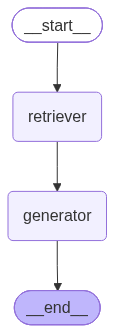

In [ ]:
# Displaying a compiled graph renders a diagram of its structure.
# (The image is rendered remotely, so this needs an internet connection; if it
# does not render, the printed node and edge list above tells you the same thing.)
print("Nodes:", list(simple_rag.get_graph().nodes))
print("Edges:", [(e.source, e.target) for e in simple_rag.get_graph().edges])

simple_rag

### Running the graph

A small helper so calling the graph reads as nicely as calling `rag_pipeline()` did. The only real
difference: we pass a **dict matching the state schema** rather than positional arguments.

In [ ]:
# ---------------------------------------------------------------------------
# Helper: send a question through the compiled graph and render the answer.
#
# The input dict must match the state schema -- here, just the question field.
# LangGraph fills in the rest as the nodes run.
# ---------------------------------------------------------------------------
def ask(question):
    """Run one question through the LangGraph pipeline and display the answer."""
    print(f"[graph] running: {question}")

    response = simple_rag.invoke({"question": question})

    print(f"[graph] completed!\n")

    display(Markdown(f"**QUESTION:** {question}"))
    display(Markdown(response["answer"]))

    sources = sorted({d.metadata["doc_title"] for d in response["retrieved_docs"]})
    display(Markdown(
        f"*{len(response['retrieved_docs'])} chunk(s) retrieved from: "
        f"{', '.join(sources) if sources else 'nothing above the threshold'}*"
    ))

    return response

### The same questions, through the graph

We re-run two questions from Part A: one that should draw on both reports, and one that should refuse.
Compare the answers to what Part A produced.

They should be equivalent. That is exactly the point — we changed the orchestration, not the pipeline.

In [ ]:
# A question Part A answered from both reports.
response = ask("""What does it mean to be credit invisible, and how do people usually stop being
                  credit invisible?""")

[graph] running: What does it mean to be credit invisible, and how do people usually stop being
                  credit invisible?
  [retriever node] 5 chunk(s) for: What does it mean to be credit invisible, and how do people usually stop being
                  credit invisible?
  [generator node] answer generated (2040 chars)
[graph] completed!



**QUESTION:** What does it mean to be credit invisible, and how do people usually stop being
                  credit invisible?

Being credit invisible means that a consumer does not have a credit record at one of the three nationwide credit reporting companies, which makes it difficult for lenders to assess their creditworthiness and thus harder for these consumers to access credit. About 11 percent of U.S. adults, or roughly 26 million people, are credit invisible [1][2].

People usually stop being credit invisible by acquiring a credit record through various means. Most consumers who transition out of credit invisibility do so at young ages, with almost 80 percent of transitions occurring before age 25. The most common way to become credit visible is by opening a credit card account, which triggers the creation of a credit record more frequently than any other product. Student loans are the next most frequent entry product, especially for younger consumers. Some consumers acquire credit records through non-loan items such as third-party collection accounts or public records, particularly those in lower-income neighborhoods. Additionally, over 20 percent of consumers who transition out of credit invisibility do so with the help of others, either by opening accounts with co-borrowers or by becoming authorized users on someone else’s account. About 15 percent first acquire their credit history through non-loan items like collections or public records, while approximately 65 percent open accounts on their own despite lacking a credit history [1].

The data do not fully explain why some credit invisible consumers are able to make this transition while others are not, suggesting that lenders may use unobservable characteristics to decide whom to lend to among the credit invisible. Efforts to reduce credit invisibility might include promoting access to banking services in lower-income communities and exploring alternative data sources such as rent or utility payments to help assess creditworthiness [1].

## References
- [1] CFPB (2017). "CFPB Data Point: Becoming Credit Visible".
- [2] CFPB (2015). "CFPB Data Point: Credit Invisibles".

*5 chunk(s) retrieved from: CFPB Data Point: Becoming Credit Visible, CFPB Data Point: Credit Invisibles*

In [ ]:
# And the near-miss refusal, to confirm grounding survived the rewrite.
response = ask("How do I dispute an error on my credit report?")

[graph] running: How do I dispute an error on my credit report?
  [retriever node] 5 chunk(s) for: How do I dispute an error on my credit report?
  [generator node] answer generated (348 chars)
[graph] completed!



**QUESTION:** How do I dispute an error on my credit report?

The provided sources do not cover how to dispute an error on a credit report. They focus on the prevalence and characteristics of consumers with limited or no credit history ("credit invisibles") and how consumers first acquire credit records, but they do not provide information or guidance on the process for disputing errors on credit reports.



*5 chunk(s) retrieved from: CFPB Data Point: Becoming Credit Visible, CFPB Data Point: Credit Invisibles*

### What the graph bought us — and what it did not

**What it bought us.** Structure. The pipeline is now a set of named nodes with declared state and
explicit edges, rather than a sequence of calls inside a function body. That structure is what makes
the next set of features cheap instead of painful: adding a node is one registration and one edge;
making a step conditional is one routing function; adding conversational memory is one argument to
`compile()`.

**What it did not buy us.** Any intelligence about *when* to do things.

Look closely at what this graph does with every single question. It retrieves. Then it generates.
Always. In that order. It did that for *"How many adults have no credit score?"* — sensible — and it
did exactly the same thing for *"What is the capital of India?"*, dutifully running a vector search
over two CFPB reports for a geography question before refusing.

The flow is hard-coded. The system has no capacity to look at a question and decide what to do about
it, because that decision was made by us, at build time, for all questions equally.

**That is the gap agents fill.** An agent is handed a set of **tools** and decides *at runtime* which
to use, in what order, and whether it needs any at all. The RAG pipeline we just built does not get
thrown away — it becomes **one tool among several**, and something else decides when to reach for it.

That is Module 2.

---
## Summary

We built a grounded question-answering system over two public-domain CFPB reports on the US consumer
credit system — twice.

**Part A — RAG as plain functions.** Five stages, each written by hand:

- **Load** — read each PDF and join its pages into one continuous text, so ideas crossing a page break
  are not cut in half
- **Chunk** — token-aware recursive splitting at 1500 tokens with 200 overlap, with **bibliographic
  metadata attached to every chunk**, because that metadata is what makes citation possible
- **Embed & store** — vectors in Chroma under cosine distance, with stable IDs so re-runs update
  rather than duplicate
- **Retrieve** — top-k *with a score threshold*, so weak matches are dropped and the retriever is
  allowed to return nothing
- **Generate** — a grounding contract in the system prompt: only these sources, inline `[n]` markers,
  a `## References` list carrying **one entry per report**, and an explicit refusal when the sources
  fall short

**Part B — the same pipeline as a graph.** State, two nodes wrapping the Part A functions, three
edges. Identical answers, different orchestration — and now a structure that can carry conditionals,
loops, and memory.

### Ideas worth carrying forward

- **Grounding is a property of the prompt *and* the retriever.** The threshold lets retrieval return
  nothing; the prompt tells the model what to do when it does. Either one alone is insufficient.
- **Metadata is not bookkeeping.** It is the difference between a citation someone can check and a
  plausible-looking string.
- **Refusal is a feature.** The most valuable test in this notebook is the near-miss question, where
  the model certainly "knows" an answer that the corpus does not support.
- **A framework manages flow, not logic.** The Part B nodes are three lines each because all the real
  work already existed.

## What comes next

In **Module 2** we hand this pipeline to an **agent**. The whole retrieve-and-generate flow gets
wrapped as a single **tool**, sitting alongside other tools that do entirely different things — and
the agent decides, per question, which one to reach for. The hard-coded `retrieve -> generate` path
becomes one option among several rather than the only thing the system can do.